# FastText + BiGRU + FNN

In [45]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

import fasttext
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import json

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

with open("/kaggle/input/results/bigru_optuna_best_params.json", "r") as f:
    best_params = json.load(f)

RANDOM_SEED = 42
N_FOLDS = 5
BATCH_SIZE = best_params['best_params']['batch_size']
MAX_LENGTH = 256
EMBEDDING_DIM = 200
HIDDEN_DIM = best_params['best_params']['hidden_dim']
NUM_LAYERS = best_params['best_params']['num_layers']
DROPOUT = best_params['best_params']['dropout']
LEARNING_RATE = best_params['best_params']['learning_rate']
WEIGHT_DECAY = best_params['best_params']['weight_decay']
NUM_EPOCHS = 15
PATIENCE = 3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
CUDA available: True
GPU: Tesla P100-PCIE-16GB


## 1. Load Data

In [46]:
# Load train and test data
DATA_DIR = Path('/kaggle/input/steam-review')
MODEL_DIR = Path('/kaggle/input/fasttext-steam-200/other/default/1')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
test_df = pd.read_csv(DATA_DIR / 'test.csv')

print(f"Train set: {len(train_df):,} reviews")
print(f"Test set: {len(test_df):,} reviews")
print("\nTrain sentiment distribution:")
print(train_df['voted_up'].value_counts(normalize=True))

Train set: 34,481 reviews
Test set: 6,086 reviews

Train sentiment distribution:
voted_up
True     0.500044
False    0.499956
Name: proportion, dtype: float64


In [47]:
# Prepare features and labels
X_train = train_df['processed_text'].fillna('').values
y_train = train_df['voted_up'].astype(int).values

X_test = test_df['processed_text'].fillna('').values
y_test = test_df['voted_up'].astype(int).values

# Create stratification key for K-Fold
stratify_key = train_df['voted_up'].astype(str) + '_' + train_df['primary_genre'].astype(str)

print(f"Features: {len(X_train):,} train, {len(X_test):,} test")
print(f"Labels: {dict(zip(*np.unique(y_train, return_counts=True)))}")

Features: 34,481 train, 6,086 test
Labels: {0: 17239, 1: 17242}


## 2. Load FastText Embeddings

In [48]:
# Load pre-trained FastText model
print("Loading FastText model...")
ft_model = fasttext.load_model(str(MODEL_DIR / 'steam_fasttext.bin'))
print(f"FastText loaded: {ft_model.get_dimension()}-dimensional embeddings")
print(f"Vocabulary size: {len(ft_model.words):,}")

Loading FastText model...
FastText loaded: 200-dimensional embeddings
Vocabulary size: 32,313


## 3. Dataset and DataLoader

In [49]:
class SteamReviewDataset(Dataset):
    """Dataset for Steam reviews with FastText embeddings."""
    
    def __init__(self, texts, labels, ft_model, max_length=256):
        self.texts = texts
        self.labels = labels
        self.ft_model = ft_model
        self.max_length = max_length
        self.embedding_dim = ft_model.get_dimension()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Tokenize and get embeddings
        tokens = text.split()[:self.max_length]
        
        # Get word embeddings
        embeddings = np.zeros((self.max_length, self.embedding_dim), dtype=np.float32)
        for i, token in enumerate(tokens):
            embeddings[i] = self.ft_model.get_word_vector(token)
        
        # Create mask for actual tokens (1 for real, 0 for padding)
        mask = np.zeros(self.max_length, dtype=np.float32)
        mask[:len(tokens)] = 1.0
        
        return {
            'embeddings': torch.tensor(embeddings, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.float32)
        }


def create_dataloader(texts, labels, ft_model, batch_size, shuffle=True):
    """Create DataLoader with optimizations."""
    dataset = SteamReviewDataset(texts, labels, ft_model, MAX_LENGTH)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=4,
        pin_memory=True
    )

## 4. Model Architecture

In [50]:
class Attention(nn.Module):
    """Self-attention layer for sequence modeling."""
    
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False)
        )
    
    def forward(self, gru_output, mask):
        # Compute attention scores
        scores = self.attention(gru_output).squeeze(-1)  # (batch, seq_len)
        
        # Mask padding tokens with large negative value
        scores = scores.masked_fill(mask == 0, -1e4)
        
        # Softmax to get attention weights
        attention_weights = torch.softmax(scores, dim=1)  # (batch, seq_len)
        
        # Weighted sum of GRU outputs
        context = torch.bmm(
            attention_weights.unsqueeze(1),  # (batch, 1, seq_len)
            gru_output  # (batch, seq_len, hidden_dim)
        ).squeeze(1)  # (batch, hidden_dim)
        
        return context, attention_weights


class SentimentClassifier(nn.Module):
    """FastText + BiGRU + Attention + FNN for sentiment classification."""
    
    def __init__(self, embedding_dim=100, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # BiGRU encoder
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention pooling
        self.attention = Attention(hidden_dim * 2)  # *2 for bidirectional
        
        # Feed-forward classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask):
        # Optimize for multi-GPU/cuDNN
        self.gru.flatten_parameters()
        
        # BiGRU encoding: (batch, seq_len, hidden_dim * 2)
        gru_output, _ = self.gru(embeddings)
        
        # Attention pooling: (batch, hidden_dim * 2)
        context, attention_weights = self.attention(gru_output, mask)
        
        # Classification: (batch, 1)
        logits = self.classifier(context)
        
        return logits

In [51]:
class SentimentClassifierFastTextOnly(nn.Module):
    """FastText + FNN Only - Ablation Baseline (No BiGRU, No Attention)."""
    
    def __init__(self, embedding_dim=100, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        # Note: num_layers is kept for API consistency but not used
        self.hidden_dim = hidden_dim
        
        # Feed-forward classifier (takes embedding_dim directly)
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask):
        # Masked average pooling over sequence
        # embeddings: (batch, seq_len, embedding_dim)
        # mask: (batch, seq_len)
        
        # Expand mask for broadcasting: (batch, seq_len, 1)
        mask_expanded = mask.unsqueeze(-1)
        
        # Sum of embeddings weighted by mask
        masked_embeddings = embeddings * mask_expanded  # (batch, seq_len, embedding_dim)
        sum_embeddings = masked_embeddings.sum(dim=1)   # (batch, embedding_dim)
        
        # Divide by number of actual tokens (avoid division by zero)
        token_counts = mask.sum(dim=1, keepdim=True).clamp(min=1)  # (batch, 1)
        avg_embeddings = sum_embeddings / token_counts  # (batch, embedding_dim)
        
        # Classification
        logits = self.classifier(avg_embeddings)
        
        return logits

In [52]:
class SentimentClassifierNoAttention(nn.Module):
    """FastText + BiGRU + FNN (No Attention) - Ablation Baseline."""
    
    def __init__(self, embedding_dim=100, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # BiGRU encoder
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Feed-forward classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask):
        self.gru.flatten_parameters()
        
        # BiGRU encoding: (batch, seq_len, hidden_dim * 2)
        gru_output, hidden = self.gru(embeddings)
        
        # Use last hidden state from both directions
        # hidden shape: (num_layers * 2, batch, hidden_dim)
        # Take last layer's forward and backward hidden states
        hidden_forward = hidden[-2, :, :]   # (batch, hidden_dim)
        hidden_backward = hidden[-1, :, :]  # (batch, hidden_dim)
        context = torch.cat([hidden_forward, hidden_backward], dim=-1)  # (batch, hidden_dim * 2)
        
        # Classification: (batch, 1)
        logits = self.classifier(context)
        
        return logits

In [53]:
# Instantiate model with config
#model = SentimentClassifier(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
#model = SentimentClassifierNoAttention(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
model = SentimentClassifierFastTextOnly(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

SentimentClassifierFastTextOnly(
  (classifier): Sequential(
    (0): Linear(in_features=200, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.37688348156490475, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total parameters: 25,857
Trainable parameters: 25,857


## 5. Training Functions

In [54]:
def train_epoch(model, dataloader, optimizer, criterion, scaler, device):
    """Train for one epoch with mixed precision."""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch in tqdm(dataloader, desc='Training', leave=False):
        embeddings = batch['embeddings'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision forward pass
        with autocast(device_type=device.type):
            logits = model(embeddings, mask).squeeze(-1)
            loss = criterion(logits, labels)
        
        # Mixed precision backward pass
        scaler.scale(loss).backward()
        
        # Gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """Evaluate model."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            
            with autocast(device_type=device.type):
                logits = model(embeddings, mask).squeeze(-1)
                loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

## 6. K-Fold Cross-Validation

In [55]:
# Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Store metrics for each fold
fold_metrics = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'best_epoch': []
}

print(f"Running {N_FOLDS}-Fold Cross-Validation")

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, stratify_key)):
    print(f"\nFold {fold + 1}/{N_FOLDS}")
    
    # Split data
    X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
    y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
    
    # Create dataloaders
    train_loader = create_dataloader(X_fold_train, y_fold_train, ft_model, BATCH_SIZE, shuffle=True)
    val_loader = create_dataloader(X_fold_val, y_fold_val, ft_model, BATCH_SIZE, shuffle=False)
    
    # Initialize model, optimizer, criterion, scaler
    #model = SentimentClassifier(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
    #model = SentimentClassifierNoAttention(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
    model = SentimentClassifierFastTextOnly(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()
    scaler = GradScaler()
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1)
    
    # Training loop with early stopping
    best_val_f1 = 0
    patience_counter = 0
    best_epoch = 0

    for epoch in range(NUM_EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler, device)
        val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_f1)
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, "
              f"Val F1={val_f1:.4f}")
        
        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_metrics = (val_acc, val_prec, val_rec, val_f1)
            best_epoch = epoch + 1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Store best metrics
    fold_metrics['fold'].append(fold + 1)
    fold_metrics['accuracy'].append(best_metrics[0])
    fold_metrics['precision'].append(best_metrics[1])
    fold_metrics['recall'].append(best_metrics[2])
    fold_metrics['f1'].append(best_metrics[3])
    fold_metrics['best_epoch'].append(best_epoch)
    
    print(f"Fold {fold + 1} Best: Accuracy={best_metrics[0]:.4f}, Precision={best_metrics[1]:.4f}, "
          f"Recall={best_metrics[2]:.4f}, F1={best_metrics[3]:.4f}")

# Create results DataFrame
results_df = pd.DataFrame(fold_metrics)

Running 5-Fold Cross-Validation

Fold 1/5


Epoch 1: Train Loss=0.4513, Val Loss=0.3841, Val F1=0.8237


Epoch 2: Train Loss=0.3860, Val Loss=0.3722, Val F1=0.8272


Epoch 3: Train Loss=0.3728, Val Loss=0.3629, Val F1=0.8421


Epoch 4: Train Loss=0.3702, Val Loss=0.3727, Val F1=0.8421


...

Epoch 11: Train Loss=0.3518, Val Loss=0.3563, Val F1=0.8396


Epoch 12: Train Loss=0.3503, Val Loss=0.3548, Val F1=0.8491


Epoch 13: Train Loss=0.3505, Val Loss=0.3515, Val F1=0.8448


Epoch 14: Train Loss=0.3485, Val Loss=0.3509, Val F1=0.8472


Epoch 15: Train Loss=0.3434, Val Loss=0.3526, Val F1=0.8495
Fold 5 Best: Accuracy=0.8483, Precision=0.8427, Recall=0.8564, F1=0.8495


In [56]:
# Summary statistics
print("CROSS-VALIDATION RESULTS SUMMARY")
print(f"\n{'Metric':<12} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    mean = results_df[metric].mean()
    std = results_df[metric].std()
    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    print(f"{metric.capitalize():<12} {mean:>10.4f} {std:>10.4f} {min_val:>10.4f} {max_val:>10.4f}")

print(f"\nMacro F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")

CROSS-VALIDATION RESULTS SUMMARY

Metric             Mean        Std        Min        Max
Accuracy         0.8461     0.0085     0.8340     0.8550
Precision        0.8371     0.0227     0.8030     0.8579
Recall           0.8607     0.0154     0.8437     0.8852
F1               0.8484     0.0051     0.8421     0.8550

Macro F1 Score: 0.8484 ± 0.0051


## 7. Final Evaluation on Test Set

In [57]:
# Train on full training set
print("Training final model on full training set...")

train_loader = create_dataloader(X_train, y_train, ft_model, BATCH_SIZE, shuffle=True)
test_loader = create_dataloader(X_test, y_test, ft_model, BATCH_SIZE, shuffle=False)

# Initialize model
#final_model = SentimentClassifier(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
#final_model = SentimentClassifierNoAttention(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
final_model = SentimentClassifierFastTextOnly(EMBEDDING_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
optimizer = torch.optim.Adam(final_model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler()

optimal_epochs = int(np.median(fold_metrics['best_epoch']))
print(f"Using {optimal_epochs} epochs for final training (median of CV best epochs: {fold_metrics['best_epoch']})")

# Train
for epoch in range(optimal_epochs):
    train_loss, train_acc = train_epoch(final_model, train_loader, optimizer, criterion, scaler, device)
    print(f"Epoch {epoch+1}/{optimal_epochs}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}")

Training final model on full training set...
Using 13 epochs for final training (median of CV best epochs: [4, 1, 13, 15, 15])


Epoch 1/13: Train Loss=0.4439, Train Acc=0.7989


Epoch 2/13: Train Loss=0.3782, Train Acc=0.8359


Epoch 3/13: Train Loss=0.3686, Train Acc=0.8401


Epoch 4/13: Train Loss=0.3636, Train Acc=0.8408


...

Epoch 9/13: Train Loss=0.3553, Train Acc=0.8469


Epoch 10/13: Train Loss=0.3547, Train Acc=0.8475


Epoch 11/13: Train Loss=0.3526, Train Acc=0.8483


Epoch 12/13: Train Loss=0.3518, Train Acc=0.8478


Epoch 13/13: Train Loss=0.3500, Train Acc=0.8490


In [58]:
# Evaluate on test set
test_loss, test_accuracy, test_precision, test_recall, test_f1, y_test_pred, y_test_true = evaluate(
    final_model, test_loader, criterion, device
)

print("\nTEST SET RESULTS")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")


TEST SET RESULTS
Accuracy:  0.8585
Precision: 0.8716
Recall:    0.8409
F1 Score:  0.8560


In [59]:
# Detailed classification report
print("\nDETAILED CLASSIFICATION REPORT")
print(classification_report(y_test_true, y_test_pred, target_names=['Negative', 'Positive']))


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.85      0.88      0.86      3043
    Positive       0.87      0.84      0.86      3043

    accuracy                           0.86      6086
   macro avg       0.86      0.86      0.86      6086
weighted avg       0.86      0.86      0.86      6086



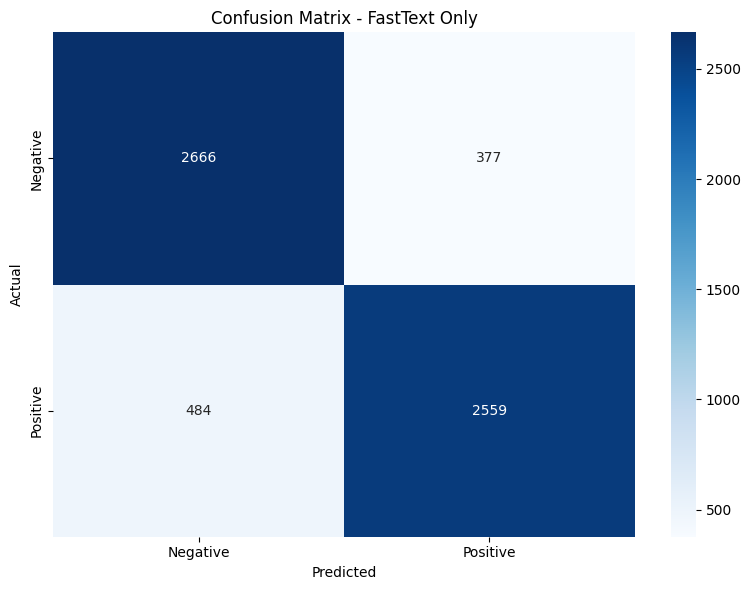


True Negatives:  2,666
False Positives: 377
False Negatives: 484
True Positives:  2,559


In [60]:
# Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - FastText Only')
plt.tight_layout()
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")

## 8. Performance by Genre

In [61]:
# Analyze performance by genre
test_df_copy = test_df.copy()
test_df_copy['predicted'] = y_test_pred
test_df_copy['correct'] = (test_df_copy['voted_up'].astype(int) == test_df_copy['predicted'])

genre_performance = test_df_copy.groupby('primary_genre').agg({
    'correct': ['sum', 'count', 'mean']
}).round(4)
genre_performance.columns = ['correct', 'total', 'accuracy']
genre_performance = genre_performance.sort_values('accuracy', ascending=False)

print("PERFORMANCE BY GENRE")
print(genre_performance.to_string())

PERFORMANCE BY GENRE
                        correct  total  accuracy
primary_genre                                   
sports                      265    292    0.9075
puzzle_matching             489    555    0.8811
hidden_object                96    111    0.8649
anime                       291    337    0.8635
science_fiction             830    963    0.8619
exploration_open_world      641    748    0.8570
action_fps                  616    719    0.8567
casual                      534    626    0.8530
rpg_action                  582    688    0.8459
survival                    575    680    0.8456
horror                      241    289    0.8339
visual_novel                 65     78    0.8333


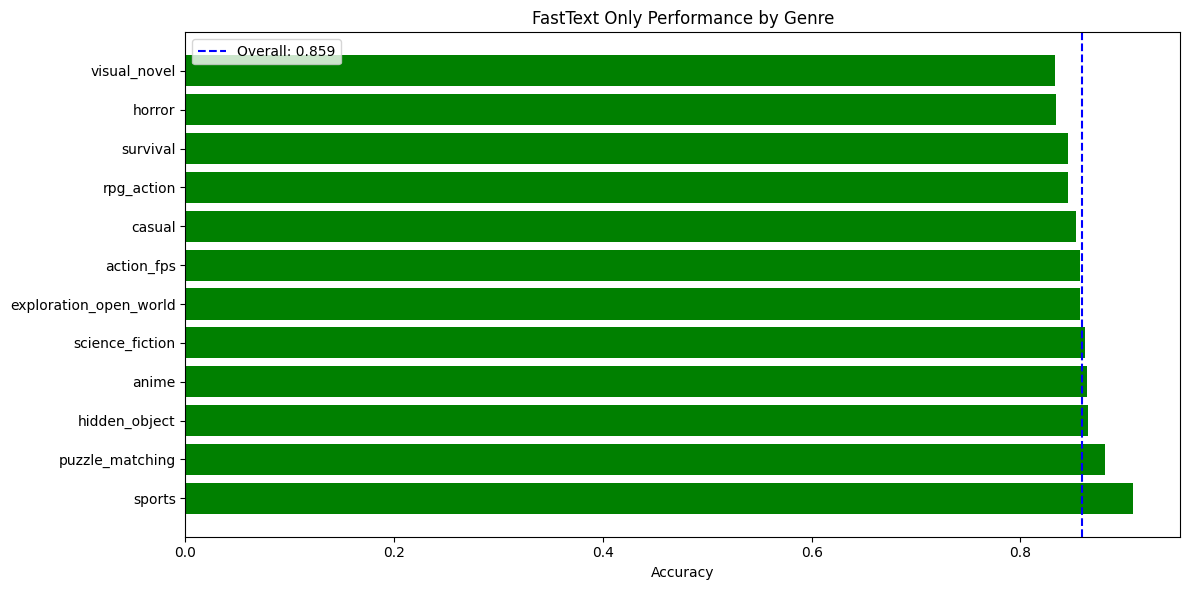

In [62]:
# Visualize genre performance
plt.figure(figsize=(12, 6))
colors = ['green' if x >= 0.75 else 'orange' if x >= 0.65 else 'red' 
          for x in genre_performance['accuracy']]
plt.barh(genre_performance.index, genre_performance['accuracy'], color=colors)
plt.xlabel('Accuracy')
plt.title('FastText Only Performance by Genre')
plt.axvline(x=test_accuracy, color='blue', linestyle='--', label=f'Overall: {test_accuracy:.3f}')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Summary & Save Results

In [63]:
# Summary
print("MODEL SUMMARY")
print("\nModel: FastText Only")
print(f"Architecture: BiGRU({HIDDEN_DIM}x2, {NUM_LAYERS} layers) + Attention + FNN({HIDDEN_DIM})")
print(f"Embeddings: FastText {EMBEDDING_DIM}-dim (pre-trained on Steam reviews)")
print(f"\nCross-Validation ({N_FOLDS}-Fold):")
print(f"  F1 Score: {results_df['f1'].mean():.4f} ± {results_df['f1'].std():.4f}")
print("\nTest Set Performance:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall:    {test_recall:.4f}")
print(f"  F1 Score:  {test_f1:.4f}")

# Compare with baseline
baseline_f1 = 0.8558
print(f"\nComparison with Baseline:")
print(f"  Baseline F1:    {baseline_f1:.4f}")
print(f"  This Model F1:  {test_f1:.4f}")
print(f"  Difference:     {test_f1 - baseline_f1:+.4f}")

MODEL SUMMARY

Model: FastText Only
Architecture: BiGRU(128x2, 2 layers) + Attention + FNN(128)
Embeddings: FastText 200-dim (pre-trained on Steam reviews)

Cross-Validation (5-Fold):
  F1 Score: 0.8484 ± 0.0051

Test Set Performance:
  Accuracy:  0.8585
  Precision: 0.8716
  Recall:    0.8409
  F1 Score:  0.8560

Comparison with Baseline:
  Baseline F1:    0.8558
  This Model F1:  0.8560
  Difference:     +0.0002


In [64]:
# Save results to JSON for comparison with other models
import json

results = {
    'model_name': 'FastText Only',
    'architecture': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'max_length': MAX_LENGTH
    },
    'cross_validation': {
        'n_folds': N_FOLDS,
        'accuracy_mean': float(results_df['accuracy'].mean()),
        'accuracy_std': float(results_df['accuracy'].std()),
        'f1_mean': float(results_df['f1'].mean()),
        'f1_std': float(results_df['f1'].std()),
        'precision_mean': float(results_df['precision'].mean()),
        'recall_mean': float(results_df['recall'].mean())
    },
    'test_set': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1': float(test_f1)
    }
}

# Save results
results_path = 'fasttext_fnn_results.json'
Path('../results').mkdir(exist_ok=True)
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")

Results saved to fasttext_fnn_results.json


In [65]:
# Save model checkpoint
model_path = 'fasttext_fnn.pt'
torch.save({
    'model_state_dict': final_model.state_dict(),
    'config': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT
    }
}, model_path)
print(f"Model saved to {model_path}")

Model saved to fasttext_fnn.pt
